In [1]:
import numpy as np
import matplotlib as plt
import pandas as pd
import seaborn as sns
import sklearn as skl

In [2]:
df=pd.read_csv('global_ev_adoption_behavior_2026.csv');
print(df.head());
print(df.isnull().sum());
print(df.isnull().sum().sum());

df['education_level']=df['education_level'].fillna(df['education_level'].mode()[0]);
df['charging_station_accessibility']=df['charging_station_accessibility'].fillna(df['charging_station_accessibility'].mean());
df['ev_knowledge_score']=df['ev_knowledge_score'].fillna(df['ev_knowledge_score'].median());


   age  annual_income education_level city_type  daily_commute_km  \
0   56        23019.0     High School  Suburban              39.8   
1   46        26440.0     High School  Suburban              34.6   
2   46        57167.0             PhD  Suburban              30.5   
3   23        15841.0          Master  Suburban              44.6   
4   50        51571.0          Master     Urban              52.4   

   weekly_travel_distance_km current_vehicle_type  vehicle_age_years  \
0                      205.7            Hatchback                6.1   
1                      218.4                Sedan                4.4   
2                      177.7                Sedan                0.4   
3                      325.9                  SUV                0.0   
4                      281.0                  SUV                5.2   

   fuel_expense_per_month  charging_station_accessibility  ...  \
0                   317.1                             3.9  ...   
1                   

In [4]:
print(df.isna().sum());
print(df.isna().sum().sum());
print(df.select_dtypes(include=np.number).corr());
print(df.describe());
print(df.duplicated().sum());

age                               0
annual_income                     0
education_level                   0
city_type                         0
daily_commute_km                  0
weekly_travel_distance_km         0
current_vehicle_type              0
vehicle_age_years                 0
fuel_expense_per_month            0
charging_station_accessibility    0
nearest_charging_station_km       0
home_charging_available           0
electricity_cost_per_kwh          0
environmental_awareness_score     0
government_incentive_awareness    0
technology_affinity_score         0
range_anxiety_score               0
battery_replacement_concern       0
ev_knowledge_score                0
previous_ev_experience            0
ev_adoption_likelihood            0
monthly_energy_consumption_kwh    0
monthly_charging_cost             0
dtype: int64
0
                                     age  annual_income  daily_commute_km  \
age                             1.000000      -0.000022         -0.006871   
ann

In [5]:
print(df.isna().sum());
print(df.isna().sum().sum());
print(df.select_dtypes(include=np.number).corr());
print(df.describe());

age                               0
annual_income                     0
education_level                   0
city_type                         0
daily_commute_km                  0
weekly_travel_distance_km         0
current_vehicle_type              0
vehicle_age_years                 0
fuel_expense_per_month            0
charging_station_accessibility    0
nearest_charging_station_km       0
home_charging_available           0
electricity_cost_per_kwh          0
environmental_awareness_score     0
government_incentive_awareness    0
technology_affinity_score         0
range_anxiety_score               0
battery_replacement_concern       0
ev_knowledge_score                0
previous_ev_experience            0
ev_adoption_likelihood            0
monthly_energy_consumption_kwh    0
monthly_charging_cost             0
dtype: int64
0
                                     age  annual_income  daily_commute_km  \
age                             1.000000      -0.000022         -0.006871   
ann

                       age  annual_income  daily_commute_km
age               1.000000      -0.000022         -0.006871
annual_income    -0.000022       1.000000          0.005468
daily_commute_km -0.006871       0.005468          1.000000


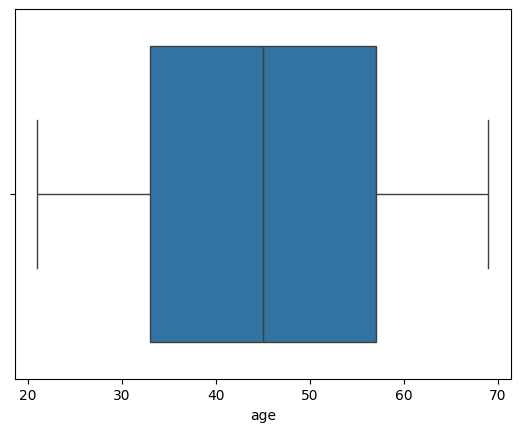

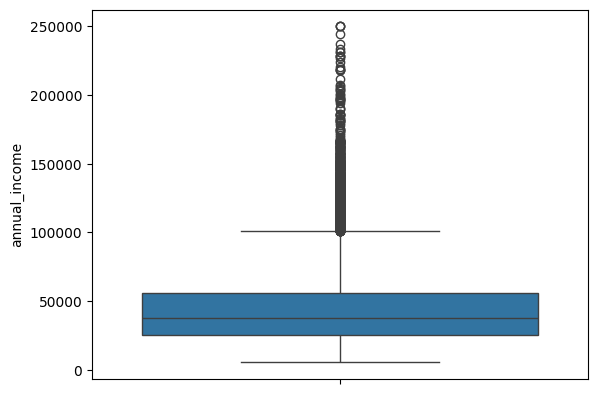

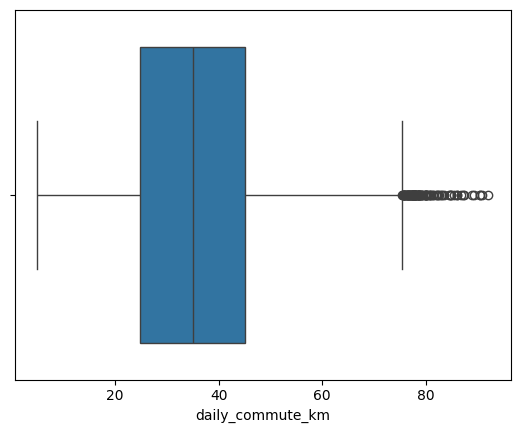

In [6]:
print(df[['age', 'annual_income', 'daily_commute_km']].corr())

sns.boxplot(df['age'], orient='h');
plt.pyplot.show();
sns.boxplot(df['annual_income'], orient='v');
plt.pyplot.show();
sns.boxplot(df['daily_commute_km'], orient='h');
plt.pyplot.show();

In [21]:
q1=df['age'].quantile(0.25);
q3=df['age'].quantile(0.75);
iqr=q3-q1;
lower_bound=q1-1.5*iqr;
upper_bound=q3+1.5*iqr;
print('the quantile(0.25) for age is:',q1,',the quantile for age (0.75) is:',q3,',the iqr is:',iqr,',lower_bound:',lower_bound,',upper bound:',upper_bound);
df=df[(df['age']>=lower_bound)&(df['age']<=upper_bound)];

the quantile(0.25) for age is: 33.0 ,the quantile for age (0.75) is: 57.0 ,the iqr is: 24.0 ,lower_bound: -3.0 ,upper bound: 93.0


In [26]:
q1=df['daily_commute_km'].quantile(0.25);
q3=df['daily_commute_km'].quantile(0.75);
iqr=q3-q1;
lower_bound=q1-1.5*iqr;
upper_bound=q3+1.5*iqr;
print('the quantile(0.25) for daily commute is:',q1,',the quantile for daily commute (0.75) is:',q3,',the iqr is:',iqr,',lower_bound:',lower_bound,',upper bound:',upper_bound);
df=df[(df['daily_commute_km']>=lower_bound)&(df['daily_commute_km']<=upper_bound)];

the quantile(0.25) for daily commute is: 24.9 ,the quantile for daily commute (0.75) is: 45.0 ,the iqr is: 20.1 ,lower_bound: -5.2500000000000036 ,upper bound: 75.15


In [25]:
q1=df['annual_income'].quantile(0.25);
q3=df['annual_income'].quantile(0.75);
iqr=q3-q1;
lower_bound=q1-1.5*iqr;
upper_bound=q3+1.5*iqr;
print('the quantile(0.25) for annual_income is:',q1,',the quantile for annual_income (0.75) is:',q3,',the iqr is:',iqr,',lower_bound:',lower_bound,',upper bound:',upper_bound);
df=df[(df['annual_income']>=lower_bound)&(df['annual_income']<=upper_bound)];

the quantile(0.25) for annual_income is: 25482.0 ,the quantile for annual_income (0.75) is: 55772.0 ,the iqr is: 30290.0 ,lower_bound: -19953.0 ,upper bound: 101207.0


outliers for age,daily_commute and annual_income has been removed and the dataset has been updated accordingly.

In [8]:
print(df.head(1))

   age  annual_income education_level city_type  daily_commute_km  \
0   56        23019.0     High School  Suburban              39.8   

   weekly_travel_distance_km current_vehicle_type  vehicle_age_years  \
0                      205.7            Hatchback                6.1   

   fuel_expense_per_month  charging_station_accessibility  ...  \
0                   317.1                             3.9  ...   

   environmental_awareness_score  government_incentive_awareness  \
0                            8.3                             6.4   

   technology_affinity_score  range_anxiety_score  \
0                        5.2                  4.6   

   battery_replacement_concern  ev_knowledge_score  previous_ev_experience  \
0                          3.5                 6.9                       0   

   ev_adoption_likelihood  monthly_energy_consumption_kwh  \
0                    High                           199.8   

   monthly_charging_cost  
0                   28.5  

[1 r

In [9]:
likelihood_mapping = {'Low': 0, 'Medium': 1, 'High': 2};
df['ev_adoption_likelihood_numeric'] = df['ev_adoption_likelihood'].map(likelihood_mapping);
print(df[['age','annual_income','fuel_expense_per_month','daily_commute_km','ev_adoption_likelihood_numeric']].corr());

                                     age  annual_income  \
age                             1.000000      -0.000022   
annual_income                  -0.000022       1.000000   
fuel_expense_per_month         -0.005834       0.005749   
daily_commute_km               -0.006871       0.005468   
ev_adoption_likelihood_numeric  0.008261       0.365044   

                                fuel_expense_per_month  daily_commute_km  \
age                                          -0.005834         -0.006871   
annual_income                                 0.005749          0.005468   
fuel_expense_per_month                        1.000000          0.951596   
daily_commute_km                              0.951596          1.000000   
ev_adoption_likelihood_numeric                0.008921          0.011104   

                                ev_adoption_likelihood_numeric  
age                                                   0.008261  
annual_income                                         0.36

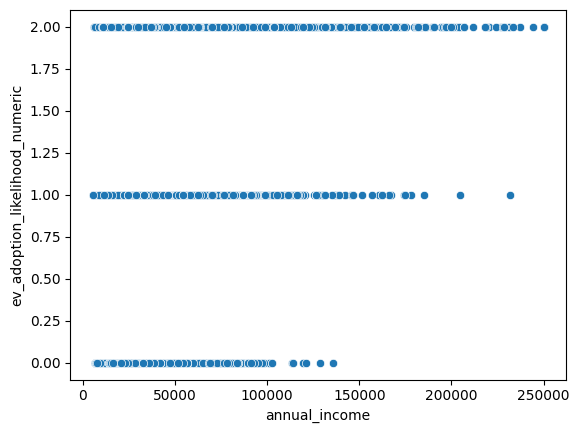

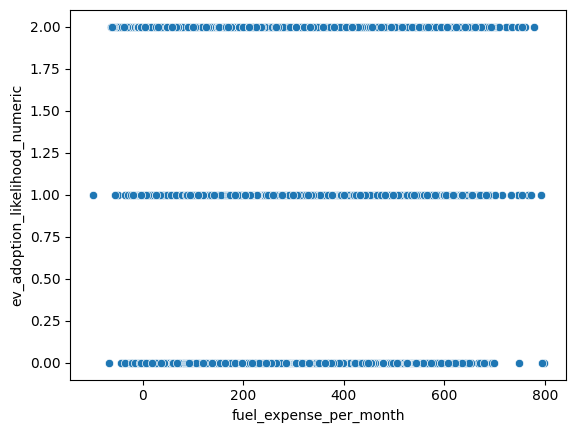

In [10]:
sns.scatterplot(data=df,x='annual_income',y='ev_adoption_likelihood_numeric');
plt.pyplot.show();
sns.scatterplot(data=df,x='fuel_expense_per_month',y='ev_adoption_likelihood_numeric');
plt.pyplot.show();

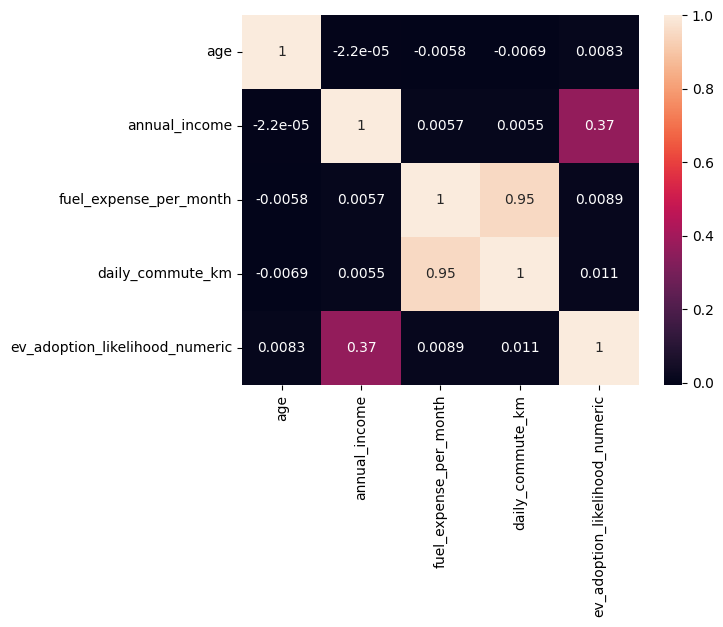

In [11]:
corr = df[['age','annual_income','fuel_expense_per_month','daily_commute_km','ev_adoption_likelihood_numeric']].corr();
sns.heatmap(corr,annot=True);
plt.pyplot.show();

In [12]:
from scipy.stats import pearsonr
pearsonr(
    df['annual_income'],
    df['ev_adoption_likelihood_numeric']
)

PearsonRResult(statistic=np.float64(0.3650443114871289), pvalue=np.float64(0.0))

my summary would be that the likelihood that one will most likely switch to an ev is based on ones own anuual income as it can be seen from the above given heatmap as well and it can also be seen from the pearson coefficient value as well.


In [16]:
from sklearn.feature_selection import VarianceThreshold

df_numeric = df.select_dtypes(include=np.number);
selector = VarianceThreshold(threshold=0.0);
selected_features = selector.fit_transform(df_numeric);
print(f"Original number of numerical features: {df_numeric.shape[1]}");
print(f"Number of features after VarianceThreshold: {selected_features.shape[1]}");
sel1=VarianceThreshold(0.01);
sel1.fit_transform(df_numeric);
print(f"Number of features after VarianceThreshold(0.01): {sel1.transform(df_numeric).shape[1]}");


Original number of numerical features: 20
Number of features after VarianceThreshold: 20
Number of features after VarianceThreshold(0.01): 19
